# Stage 1 – Data Exploration & Preprocessing

## 1. Project Overview
A short description of the project along with its aims and data file.

## 2. Loading Data
The purpose of this step is to import all required files and check their basic structures.

## 3. Initial Data Overview
Take a look at the information, the shapes, missing values, and data types. 

## 4. Exploration by Data Type

#### 4.1 Metadata A (Numerical)
Histograms and boxplots for distribution analysis Focus on skewness, outliers, and missing data strategy

#### 4.2 Metadata B (Categorical)
Countplots and detect invalid values using the data dictionary

#### 4.3 Brain Connectome
Check distributions in a few columns I can visualize each row as an image via `np.triu`.

#### 4.4 Labels
I created a graph that visualizes ADHD and sex distributions

## 5. Splitting the Data

To ensure consistency and avoid data leakage, I split the dataset **based on participant IDs** before any cleaning or feature selection. This guarantees that the same individuals are present in all training/test sets across the various data sources (metadata A, metadata B, connectome, labels).

## 6. Data Cleaning and Imputation and Feature Selection

I applied targeted cleaning strategies for missing values based on data type and distribution insights:

#### Data Cleaning and Imputation for Metadata A
- 6.1 Metadata A: Checking Missing Values and Skewness in Metadata A (Train Set).
- 6.2 Metadata A: Applying IterativeImputer to Train and Test Sets.
- 6.3 Metadata A: Final NaN Check After Imputation.
- 6.4 Metadata A: Distribution Comparison Before and After Imputation.
  
#### Feature Selection for Metadata A
- 6.5 Metadata A: Preparing Data for Feature Selection (Mutual Information)
- 6.6 Metadata A: Feature Selection Using Mutual Information
- 6.7 Final Feature Selection for Metadata A: Keeping Top 10 Features Only

#### Data Cleaning and Imputation for Metadata B
- 6.8 Metadata B: Column Types and Missing Value Overview (Train Set)
- 6.9 Metadata B: Value Distribution Before Imputation (Train Set)
- 6.10 Metadata B: Imputing Categorical Column in Train and Test Sets Using Function
- 6.11 Metadata B: Distribution of Categorical Column After Imputation (Train Set Only)

#### Feature Selection for Metadata B
- 6.12 Feature Selection in Metadata B: Top 10 Categorical Features using Mutual Information
- 6.13 Visualizing Mutual Information of Top 5 Features
  
#### Brain Conectome
- 6.14 Brain Connectome: Feature Selection Using KernelPCA


## 7. Merging the Data

- 7.1 Renaming Feature - Selected Metadata A Sets for Export
- 7.2 Exporting Final Cleaned and Reduced Datasets to CSV Files
- 7.3 Merging All Processed Data into Final Train and Test Sets
   







-------------------------------------------------------------------------------------------------------------------------

## 1. Project Overview
This NHS Data Science project will use fMRI scans and a child’s demographic data to assist in the early and accurate diagnosis of Attention Deficit Hyperactivity Disorder (ADHD) in children and adolescents. Girls are underdiagnosed for ADHD and this project will try to build a fair and explainable classification system.

I am given four types of data.
- **Brain connectome data** (fMRI connectivity matrix).
- **Metadata A**: numerical data (e.g., age, SDQ questionnaire, and so on).
- **Metadata B**: categorical data (e.g., handedness, parental education, APQ parenting style).
- **Labels**: ADHD diagnosis and biological sex.
  
The goals of Stage 1 are
- I should Understand and visualize the data.
- Find Missing values or data problems.
- Gathering useful insights for modelling stage. 

The final model that I must create.
- **Fair (bias-aware)** does not favour a gender.
- **Explainable**, using techniques like SHAP or LIME.


## 2. Loading Data

In [2]:
import pandas as pd

#I set the paths to the data files
data_path = '../data/'

file_connectome = data_path + 'FUNCTIONAL_CONNECTOME_MATRICES.csv'
file_labels = data_path + 'LABELS.xlsx'
file_metadata_a = data_path + 'METADATA_A.xlsx'
file_metadata_b = data_path + 'METADATA_B.xlsx'

#Loading data files
df_connectome = pd.read_csv(file_connectome)
df_labels = pd.read_excel(file_labels)
df_metadata_a = pd.read_excel(file_metadata_a)
df_metadata_b = pd.read_excel(file_metadata_b)

#Checking basic info for each dataset
print("Connectome shape:", df_connectome.shape)
print("Labels shape:", df_labels.shape)
print("Metadata A shape:", df_metadata_a.shape)
print("Metadata B shape:", df_metadata_b.shape)


Connectome shape: (1213, 19901)
Labels shape: (1213, 3)
Metadata A shape: (1213, 19)
Metadata B shape: (1213, 10)


The shapes of the datasets printed above confirm that the file loaded correctly and the data is ready for review


## 3. Initial Data Overview

In [4]:
# I used Function to summarize a dataframe
def inspect_dataframe(df, name):
    print(f"\nDataset: {name}")
    print("Shape:", df.shape)
    
    #print("Columns:", df.columns.tolist())       # This line of code is data dump, so I ignore that.
    #display(df.head())                       

    
    print("\nData Types and Non-Null Count:")
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nFirst 5 rows:")
    #display(df.head())
    print("-" * 80)

#Apply the inspection function to each dataset
inspect_dataframe(df_connectome, "Functional Connectome")
inspect_dataframe(df_labels, "Labels")
inspect_dataframe(df_metadata_a, "Metadata A")
inspect_dataframe(df_metadata_b, "Metadata B")



Dataset: Functional Connectome
Shape: (1213, 19901)

Data Types and Non-Null Count:

Missing values:
participant_id          0
0throw_1thcolumn        0
0throw_2thcolumn        0
0throw_3thcolumn        0
0throw_4thcolumn        0
                       ..
196throw_198thcolumn    0
196throw_199thcolumn    0
197throw_198thcolumn    0
197throw_199thcolumn    0
198throw_199thcolumn    0
Length: 19901, dtype: int64

First 5 rows:
--------------------------------------------------------------------------------

Dataset: Labels
Shape: (1213, 3)

Data Types and Non-Null Count:

Missing values:
participant_id    0
ADHD_Outcome      0
Sex_F             0
dtype: int64

First 5 rows:
--------------------------------------------------------------------------------

Dataset: Metadata A
Shape: (1213, 19)

Data Types and Non-Null Count:

Missing values:
participant_id                  0
EHQ_EHQ_Total                   0
ColorVision_CV_Score            0
APQ_P_APQ_P_CP                  0
APQ_P_APQ_P_

### Summary of Initial Data Overview

 I have inspected all four datasets in terms of:

- Shape (rows and columns)
- Column names
- Data types
- Missing values
- First 5 data samples

**Observations:**

- Metadata A consists of numerical features like age and SDQ scores. One of the columns has a fair number of missing values which will have to be handled later on.
- Metadata B includes categorical features like handedness and parental education and so on. I Check the data types to make sure read as categorical.
- Functional Connectome has information that has many dimensions. It needs more study to see how it spreads and what it needs in size.
- Labels contain the two targets: ADHD diagnosis and biological sex. I will visualize their distribution in the next steps.

These findings will guide my choices in data cleaning, visualization, and model planning.


## 4. Exploration by Data Type
### 4.1 Metadata A (Numerical)


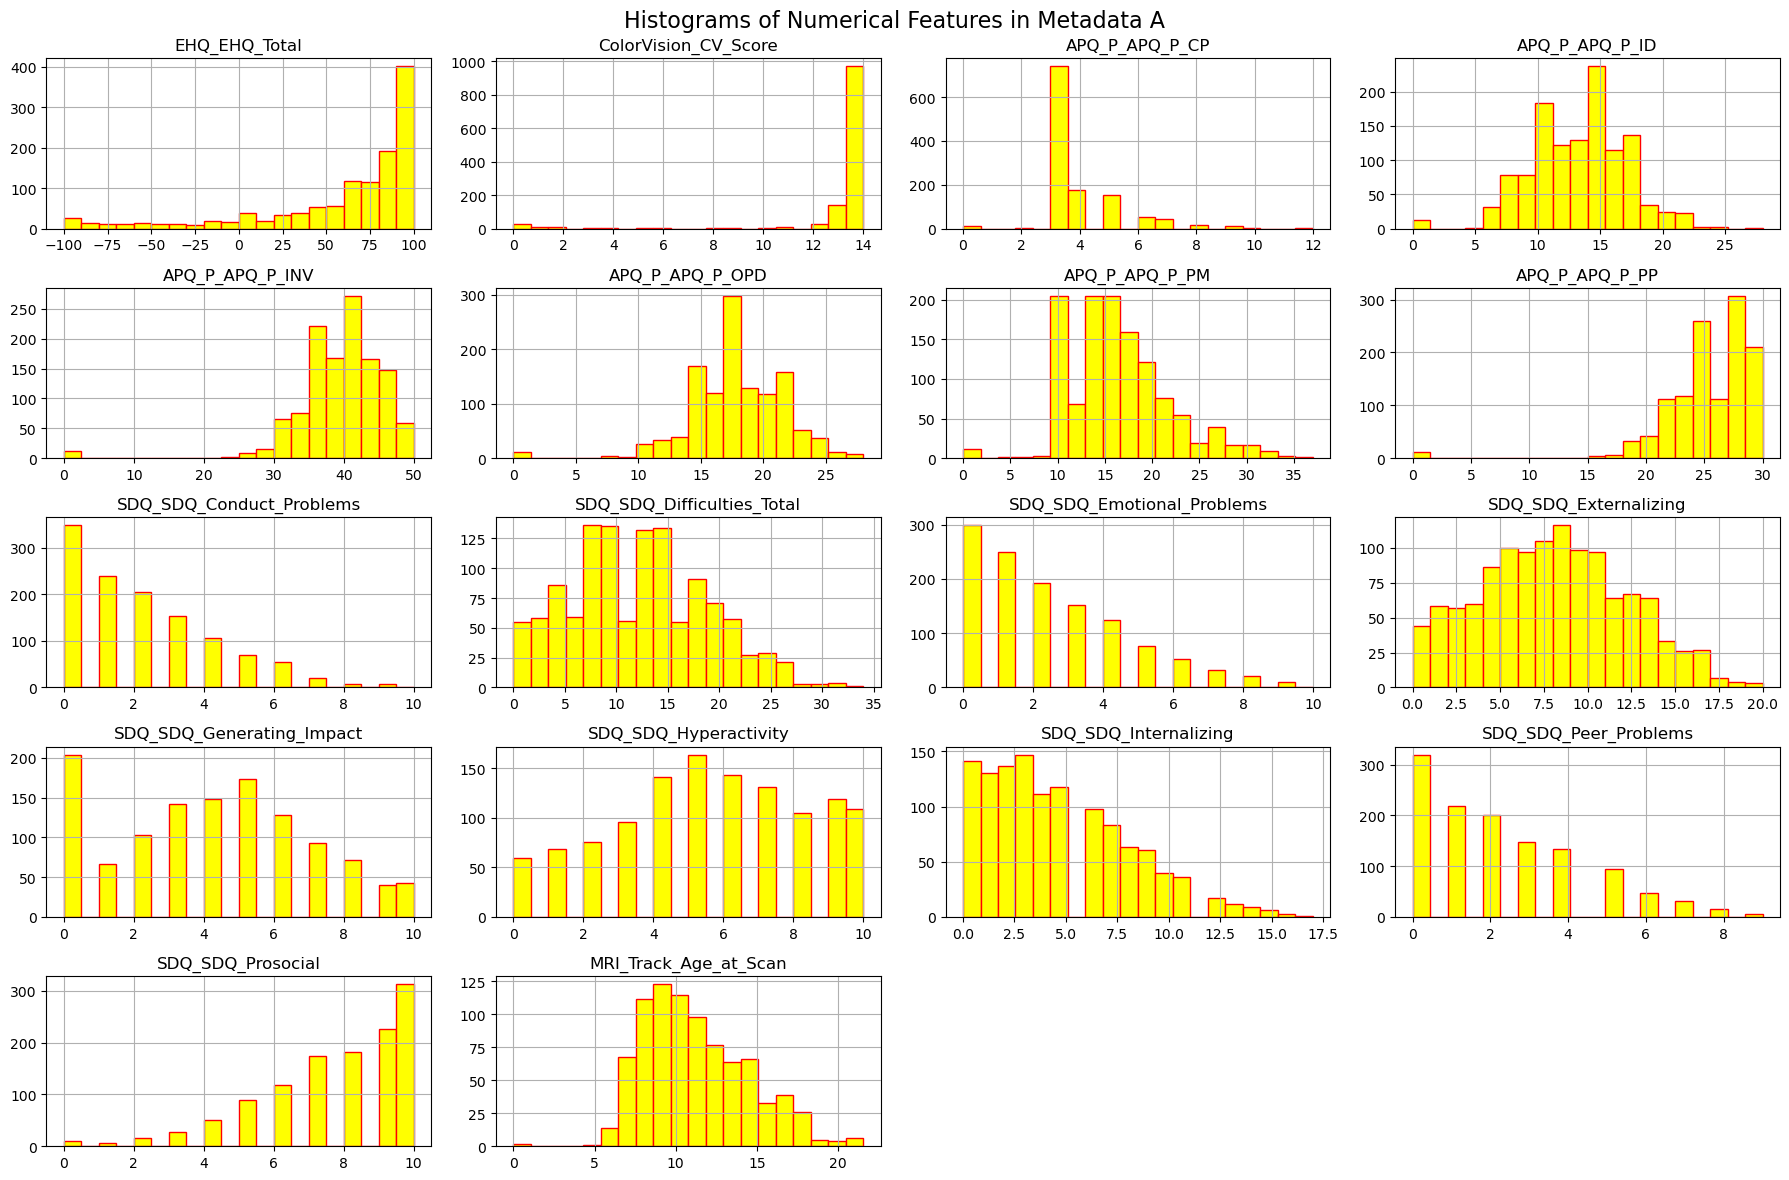

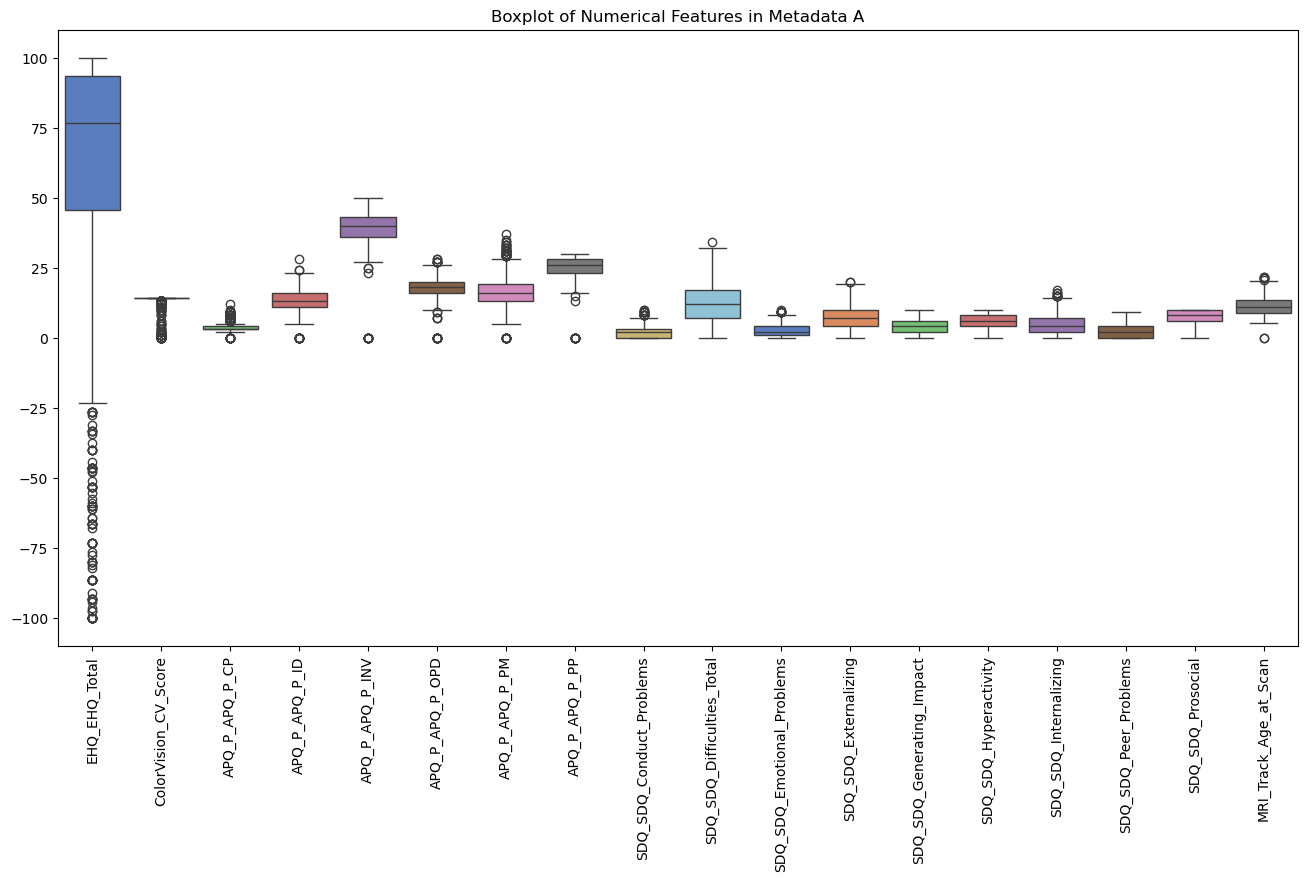

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#Function for drawing the histogram
def plot_histograms(df, title="Histograms of Numerical Features"):
    
    #I put the visualization setting for my chart
    plt.style.use("default")
    sns.set_palette("pastel")

    #Draw the histogram for all of the columns of the metadata A
    df.hist(bins=20, figsize=(18, 12), edgecolor='Red',color='Yellow')
    plt.suptitle("Histograms of Numerical Features in Metadata A", fontsize=16)
    plt.tight_layout()
    plt.show()


# I Put the function for the boxplot 
def plot_boxplots(df, title="Boxplots of Numerical Features",palette='muted'):
    # Draw the boxplot for all of the columns separately
    plt.figure(figsize=(16, 8))
    sns.boxplot(data=df, palette=palette)
    plt.xticks(rotation=90)
    plt.title("Boxplot of Numerical Features in Metadata A")
    plt.show()


# call my funcuction
plot_histograms(df_metadata_a)
plot_boxplots(df_metadata_a, palette='muted')


### Summary of Metadata A Exploration
my view based on the histograms and boxplots

- Several numerical features are positively skewed like SDQ_Emotional_Problems, and MRI_Track_Age at Scan.  If missing values are present in these features, they may require median imputation or the use of a KNNImputer.
-  Many features show clear outliers, especially EHQ_EHQ_Total, which also has negative values that need to be verified (as total scores should not be negative).
- This will help me decide how to deal with the missing values and transform the features afterward.


###  Numerical Analysis – Skewness & Outlier Detection
I will now explore the numerical attributes in Metadata A using two functions.
- I will use a function that checks for any skewness in the features.
- One function looks for outliers using the IQR method.
Examination of statistical distributions helps to decide on preprocessing.


### Skewness & Outlier Detection (Metadata A)

In [11]:
#  I put the function to show skewness values of numeric columns
def show_skewness(df):

    
    print(" Skewness of numerical features:")
    skew_vals = df.skew(numeric_only=True).sort_values(ascending=False)
    print(skew_vals)

# I write the function to detect outliers using the IQR method
#def detect_outliers_iqr(df):
    
   # print("\n Outlier summary using IQR method:")
    #for col in df.select_dtypes(include='number').columns:
     #   Q1 = df[col].quantile(0.25)
      #  Q3 = df[col].quantile(0.75)
       # IQR = Q3 - Q1
        #lower = Q1 - 1.5 * IQR\
        #upper = Q3 + 1.5 * IQR
        #outliers = df[(df[col] < lower) | (df[col] > upper)]
        #print(f"{col}: {len(outliers)} outliers")



#Results:Now I run both functions on df_metadata_a to inspect skewness and outlier counts.

show_skewness(df_metadata_a)
#detect_outliers_iqr(df_metadata_a) 



 Skewness of numerical features:
APQ_P_APQ_P_CP                1.571377
SDQ_SDQ_Conduct_Problems      1.007941
SDQ_SDQ_Emotional_Problems    0.934296
SDQ_SDQ_Peer_Problems         0.803060
SDQ_SDQ_Internalizing         0.722892
APQ_P_APQ_P_PM                0.588060
MRI_Track_Age_at_Scan         0.543932
SDQ_SDQ_Difficulties_Total    0.301522
SDQ_SDQ_Externalizing         0.175734
SDQ_SDQ_Generating_Impact     0.171464
SDQ_SDQ_Hyperactivity        -0.156734
APQ_P_APQ_P_ID               -0.189873
APQ_P_APQ_P_OPD              -0.906061
SDQ_SDQ_Prosocial            -0.985461
EHQ_EHQ_Total                -1.622435
APQ_P_APQ_P_INV              -2.484126
APQ_P_APQ_P_PP               -2.712986
ColorVision_CV_Score         -4.006743
dtype: float64


### Summary of Skewness & Outlier Detection (Metadata A)

My preprocessing strategy for numerical features in Metadata A has been determined from the results of skewness and outlier detection.

Highly skewed features.
- Some features show very strong positive (Right) skewness (1.57, 1, and 0.93).
- Features like ColorVision_CV_Score, APQ_P_APQ_P_PP and APQ_P_APQ_P_INV are strong left skewed.

To reduce bias, these may require median-based imputation.

Outlier presence.
- The major outlier variables in the Boxplot are ColorVision_CV_Score , APQ_P_APQ_P_CP , EHQ_EHQ_Total.
- Several features (e.g. SDQ_SDQ_Generating_Impact, SDQ_SDQ_Prosocial) have 0 outliers.

This means that outliers should not just be removed easily, but they need to be treated on purpose.
Possible strategies include.
- Clipping is when you set extreme values to a limit.
- I can use strong models or less-sensitive preprocessing approaches (e.g. RobustScaler, Random Forest) to outliers.
Using these approaches keeps important information but the extreme values don’t affect the working of model.

**EHQ_EHQ_Total** needs attention.
- It exhibits high skewness of -1.62 and there are many outliers 110.
- Another examination must be conducted on the negative values as these could be invalid for the total score. 

Later on, I will use this information to impute missing values, merge variables, and create other preprocessing pipelines.


### 4.2 Metadata B (Categorical)


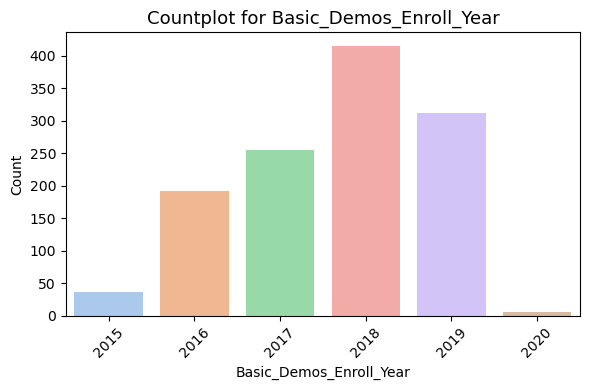

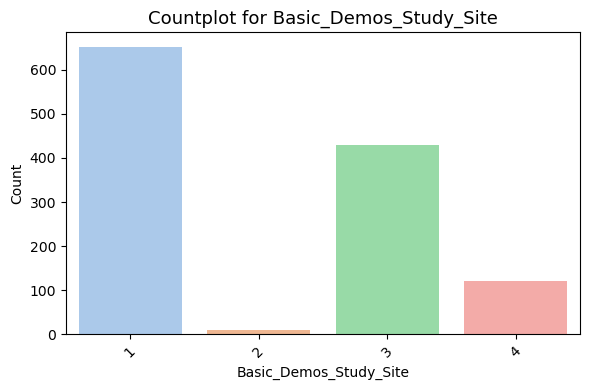

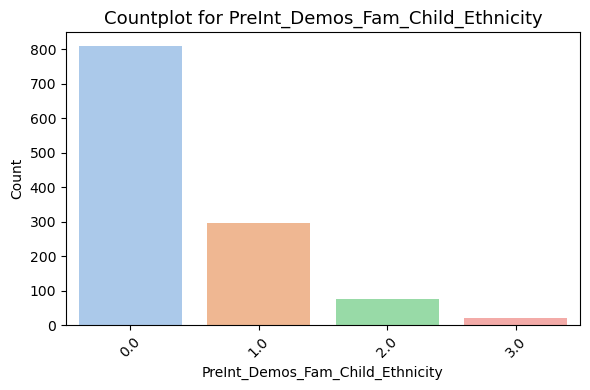

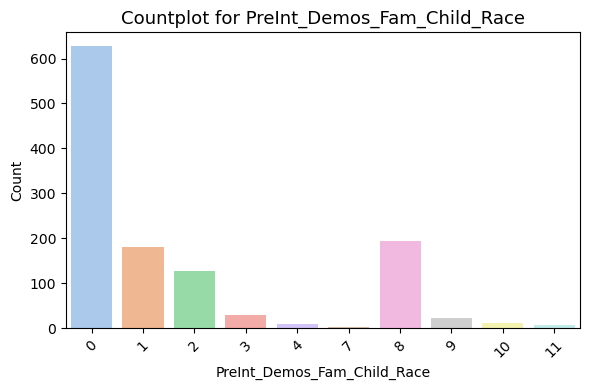

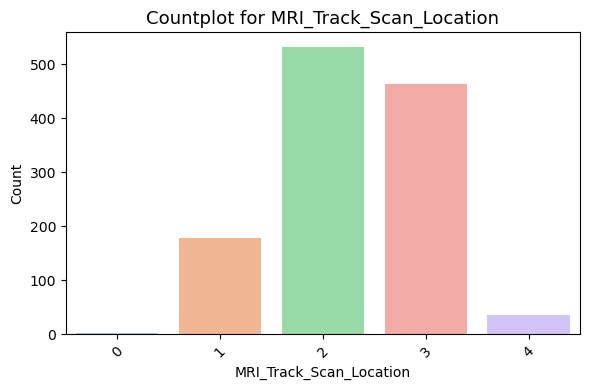

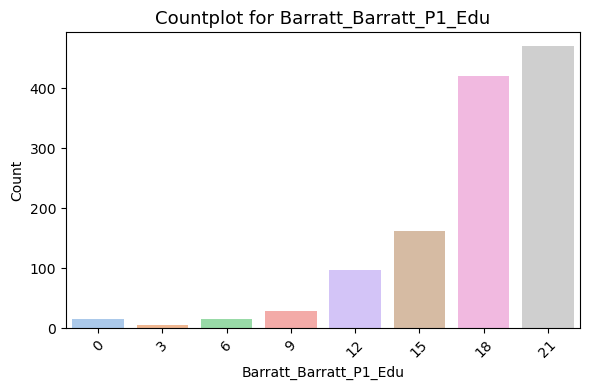

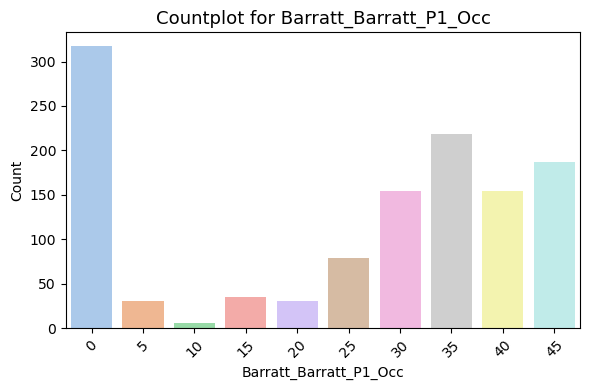

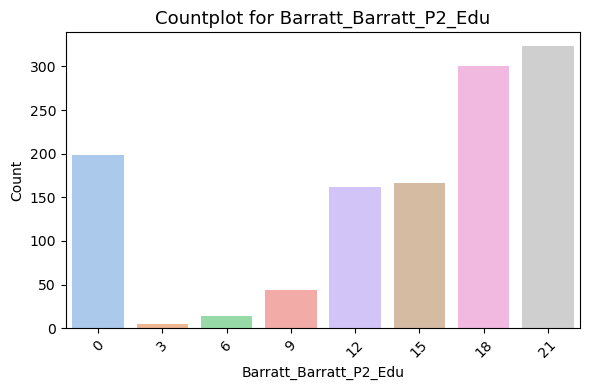

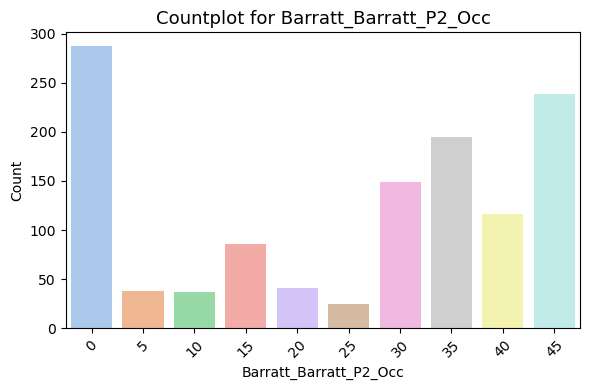

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") # i put this code for ignore the color error

# I set my  visual style
sns.set(style="whitegrid")
plt.style.use("default")

#  I use the function to draw countplots for Metadata B
def plot_metadata_b_countplots(df, title_prefix="Countplot for"):
    # Select all numeric columns (int64, float64) except participant_id
    categorical_cols = [col for col in df.columns if (df[col].dtype in ['int64', 'float64']) and col != "participant_id"]

    for col in categorical_cols:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=col, palette="pastel")
        plt.title(f"{title_prefix} {col}", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


plot_metadata_b_countplots(df_metadata_b)


### Summary of Metadata B – Categorical Feature Distributions.

To explore the categorical feauters in Metadata B I ploted counts for all columns except for participant_id. These plots allow me to.

- Learn how each categorical response distribution will look like.
- I spot the problems like:
- Unusual or highly unlikely categories.
- Distributing the data that can affect the fairness of a model.

All invalid or unexpected values suggest that the study of the data will occur to help inform the preprocessing.




### 4.3 Brain Connectome


Connectome shape: (1213, 19901)

Missing values per column:
0

Summary statistics for sample columns:
       0throw_1thcolumn  0throw_2thcolumn  0throw_3thcolumn  0throw_4thcolumn  \
count       1213.000000       1213.000000       1213.000000       1213.000000   
mean           0.060553          0.122315          0.060268          0.041287   
std            0.064178          0.054026          0.057495          0.043491   
min           -0.183279         -0.059932         -0.145566         -0.127827   
25%            0.018482          0.086102          0.026548          0.014457   
50%            0.058276          0.123220          0.061339          0.043246   
75%            0.100103          0.154518          0.099056          0.068408   
max            0.321522          0.390895          0.278429          0.189825   

       0throw_5thcolumn  
count       1213.000000  
mean           0.069722  
std            0.044222  
min           -0.072043  
25%            0.042462  
50%         

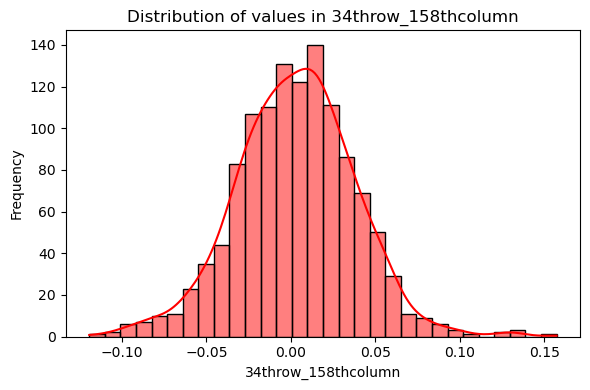

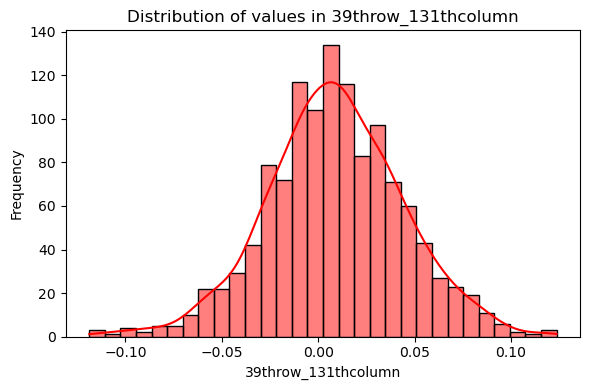

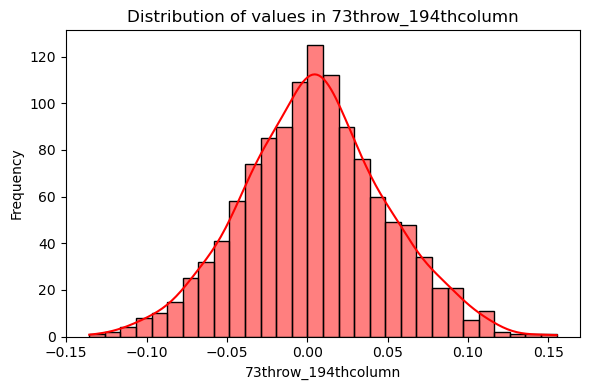

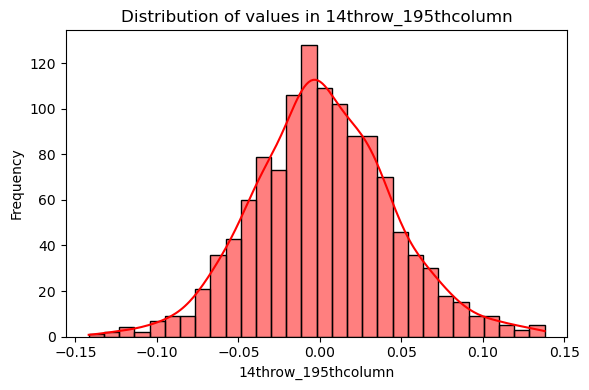

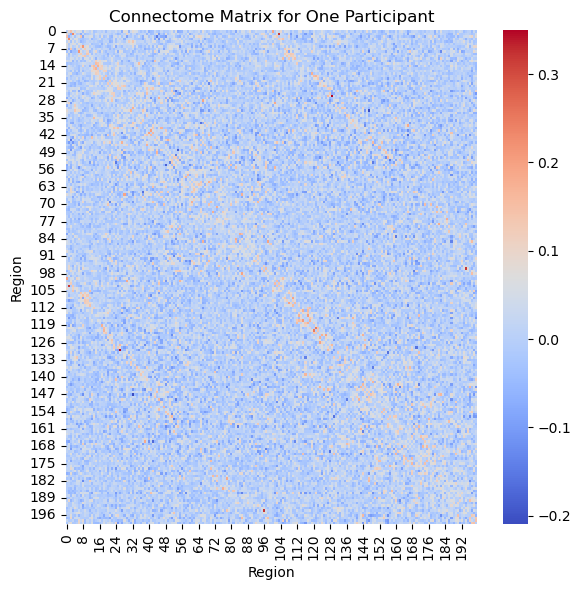

In [10]:
# 4.3 Brain Connectome (Numerical, High-Dimensional Data)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#  I put the check shape and missing values
print("Connectome shape:", df_connectome.shape)
print("\nMissing values per column:")
print(df_connectome.isnull().sum().sum())

#  I worte the code for display summary statistics of a few random columns
sample_cols = df_connectome.columns[1:6]  # Skip participant_id
print("\nSummary statistics for sample columns:")
print(df_connectome[sample_cols].describe())

#   I Showing plot distribution of values in a few random columns
def plot_connectome_distributions(df, n_cols=4):
    import random
    numeric_cols = df.select_dtypes(include='float64').columns.tolist()
    sample = random.sample(numeric_cols, n_cols)
    
    for col in sample:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], bins=30, kde=True, color='Red')
        plt.title(f"Distribution of values in {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


# Call the function
plot_connectome_distributions(df_connectome)



#  I used the function to convert a connectome vector to matrix and visualize it
def visualize_connectome_row(row_vector, matrix_size=200):
    matrix = np.zeros((matrix_size, matrix_size))
    upper_tri_indices = np.triu_indices(matrix_size, k=1)
    matrix[upper_tri_indices] = row_vector
    matrix += matrix.T  # make it symmetric

    plt.figure(figsize=(6, 6))
    sns.heatmap(matrix, cmap="coolwarm", cbar=True)
    plt.title("Connectome Matrix for One Participant")
    plt.xlabel("Region")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()

# Select the first participant's connectome vector (excluding ID)
row_vector = df_connectome.iloc[0, 1:].values
visualize_connectome_row(row_vector)




### Summary of Brain Connectome Exploration.

The Brain Connectome dataset has 19,901 numerical features representing the pairwise functional connections between brain regions as extracted from fMRI scans. Each row corresponds to a participant.

Missing Values and Summary Statistics.
- This dataset is complete and doesn't have missing values.
- Summary Statistics from Random Sample Columns show:
- The average values or the “means” are close to zero, around 0.06 for instance.
- The standard deviation values are low.
-The value range is typically between −0.2 and +0.3, suggesting weak/moderate connectivity strengths.

This shows the dataset has already been standardized or z-scored (common in neuroimaging data).

Distribution of Random Features.
- I made the histograms with KDE for 4 random features.
- The distributions are normally centred around zero. 
- the features are symmetric, though they may be slightly skewed.
- Most values are concentrated near zero, with a few spread toward the tails.

This lends support to the idea that many features may not provide much information by themselves, emphasizing the need for dimensionality reduction or regularized models.

Connectome Matrix Visualization.
-  I visualized a single participant’s connectome vector using **np.triu()** to reconstruct the upper triangle of the correlation matrix.
- This shows how strong the connections are between different areas.
- Most of the heatmap shows low correlations (light blue), with some high values (red).
-  No strong block structures or clear clustering patterns are visible, indicating low global correlation structure


Preprocessing Implications.
- The features are so poorly correlated that PCA is not appropriate.
- Instead, I will consider:
- **KernelPCA** with hyperparameter tuning.
- I can also use regularization while training a model to choose informative connections. 
- No additional transformation is required at this stage as the data is well-scaled and clean.

This finding will guide me in the next stage of the project regarding the dimensionality reduction and feature selection we should follow.

### 4.4 Labeles

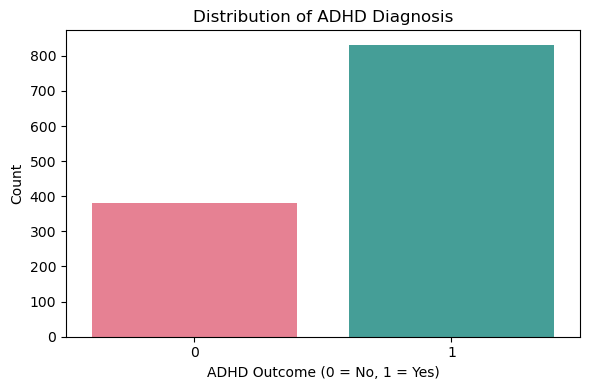

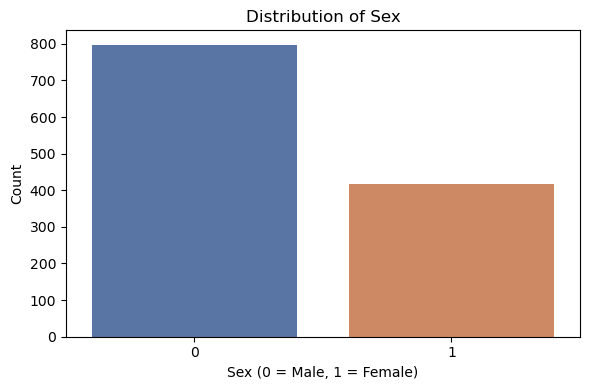

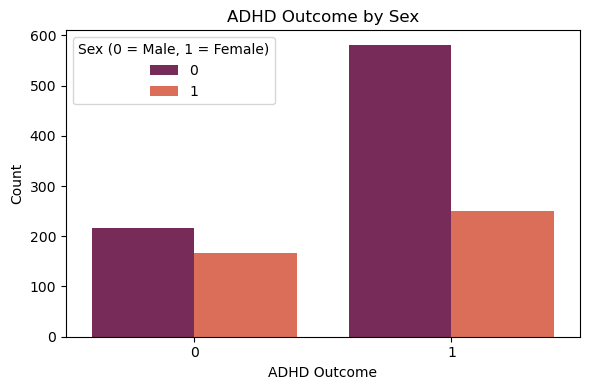

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# My chart ADHD Outcome
plt.figure(figsize=(6, 4))
sns.countplot(data=df_labels, x="ADHD_Outcome", palette="husl")
plt.title("Distribution of ADHD Diagnosis")
plt.xlabel("ADHD Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# My chart for Sex
plt.figure(figsize=(6, 4))
sns.countplot(data=df_labels, x="Sex_F", palette="deep")
plt.title("Distribution of Sex")
plt.xlabel("Sex (0 = Male, 1 = Female)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Combined: ADHD Outcome by Sex
plt.figure(figsize=(6, 4))
sns.countplot(data=df_labels, x="ADHD_Outcome", hue="Sex_F", palette="rocket")
plt.title("ADHD Outcome by Sex")
plt.xlabel("ADHD Outcome")
plt.ylabel("Count")
plt.legend(title="Sex (0 = Male, 1 = Female)")
plt.tight_layout()
plt.show()


###  Summary of 4.4 Labels – ADHD and Sex Distribution.

I examine the distributions of labels in order to understand the dataset better and detect bias.

### ADHD Diagnosis Distribution:.

A greater number of participants (around 67%) has been assessed to having ADHD (1) while the lesser does not have it (0).

The uneven distribution may call for stratified sampling or auto-balancing during training phase.

### Sex Distribution:

There are more males in the data than females, with roughly twice as many males to females. Males (0) are coded neutrally, whereas females (1) are coded with a positive attribute. This observation is in line with clinical observations that males tend to get diagnosed with ADHD more often, but it also raises the need to maintain gender fairness in the model.

### ADHD Outcome by Sex:

The ADHD diagnosis of males (0) exceeds that of females (1) in an approximate ratio of 2 to 1.

This endorses the creation of a bias-aware model which does not overfit to male ADHD patterns.

I need to identify the correct model classes according to those results. I should further carry out a bias analysis and bring in explainability at a later stage.

## 5. Splitting the Data

In [12]:
from sklearn.model_selection import train_test_split

#  I wrote the code for extracting unique participant IDs from the labels dataframe
participant_ids = df_labels["participant_id"].unique()

df_stratify = df_labels.set_index("participant_id").loc[participant_ids]

#  I created  a new column that combines ADHD and Sex (4 possible categories: 0–3)
df_stratify["ADHD_Sex_Group"] = df_stratify["ADHD_Outcome"] * 2 + df_stratify["Sex_F"]

# Use the new combined column for stratification
train_ids, test_ids = train_test_split(
    participant_ids,
    test_size=0.2,
    random_state=42,
    stratify=df_stratify["ADHD_Sex_Group"]
)

#  I Explained here for ADHD_Sex_Group mapping
print("Mapping of ADHD_Sex_Group values:")
print("0 → Male without ADHD")
print("1 → Female without ADHD")
print("2 → Male with ADHD")
print("3 → Female with ADHD")

# Count number of samples in each of the 4 combined groups (ADHD + Sex)
print("\nTrain set distribution across ADHD+Sex groups:")
print(df_stratify.loc[train_ids]["ADHD_Sex_Group"].value_counts().sort_index())

print("\nTest set distribution across ADHD+Sex groups:")
print(df_stratify.loc[test_ids]["ADHD_Sex_Group"].value_counts().sort_index())


print("\n")

#   I wrote these two lines of code to convert lists to sets for faster filtering
train_ids_set = set(train_ids)
test_ids_set = set(test_ids)

#  I used a function to split any dataframe using participant_id
def split_by_ids(df, id_column="participant_id"):
    df_train = df[df[id_column].isin(train_ids_set)].copy()
    df_test = df[df[id_column].isin(test_ids_set)].copy()
    return df_train, df_test

#  Apply the split function to all datasets
metadata_a_train, metadata_a_test = split_by_ids(df_metadata_a)
metadata_b_train, metadata_b_test = split_by_ids(df_metadata_b)
connectome_train, connectome_test = split_by_ids(df_connectome)
labels_train, labels_test = split_by_ids(df_labels)

# Check the number of rows in each split
print("Metadata A:", metadata_a_train.shape, "(train)", metadata_a_test.shape, "(test)")
print("Metadata B:", metadata_b_train.shape, "(train)", metadata_b_test.shape, "(test)")
print("Connectome:", connectome_train.shape, "(train)", connectome_test.shape, "(test)")
print("Labels:", labels_train.shape, "(train)", labels_test.shape, "(test)")

print("\n")

#  I calculate the total number of participants
total = len(train_ids) + len(test_ids)

#  Wroting the code for calculate percentages
train_percent = len(train_ids) / total * 100
test_percent = len(test_ids) / total * 100


print(f" Data was split into {train_percent:.0f}% train and {test_percent:.0f}% test.")


print("\n")

# I check for participant ID overlap between training and testing sets
overlap = train_ids_set.intersection(test_ids_set)

#  I wrote this code to show how many overlapping IDs exist
print(f"Number of overlapping participant IDs: {len(overlap)}")

#  I wrote  code optionally to display overlapping IDs (for debugging)
if len(overlap) > 0:
    print("Overlapping IDs:")
    print(list(overlap))


# I found that if the result > 0, it means my splitting code has a problem, but if the result|= 0, it means I didn't have overlapping


Mapping of ADHD_Sex_Group values:
0 → Male without ADHD
1 → Female without ADHD
2 → Male with ADHD
3 → Female with ADHD

Train set distribution across ADHD+Sex groups:
ADHD_Sex_Group
0    173
1    133
2    464
3    200
Name: count, dtype: int64

Test set distribution across ADHD+Sex groups:
ADHD_Sex_Group
0     43
1     33
2    117
3     50
Name: count, dtype: int64


Metadata A: (970, 19) (train) (243, 19) (test)
Metadata B: (970, 10) (train) (243, 10) (test)
Connectome: (970, 19901) (train) (243, 19901) (test)
Labels: (970, 3) (train) (243, 3) (test)


 Data was split into 80% train and 20% test.


Number of overlapping participant IDs: 0


 ### 5.Summary of Splitting the Data – Analysis

To evaluate the models fairly and prevent data leakage for me, ADHD_Outcome label was used to do a stratified train-test split of the data into 80% train and 20% test. This way,  the train and test set has same proportions for ADHD as well as others.

### Key points of my approach.

I separated the data into 80 percent train and 20 percent test which maintained the distribution of ADHD_Outcome values.
I split the datasets based on participant_id. This way, there is no participant who is present in both train and test sets for all datasets (i.e. Metadata A, Metadata B, Connectome, Labels). 
I created a function which can split any dataset using the participant_id list. 
This led to splitting each dataset into a training group of 970 participants and a testing group of 243 participants.
I checked for participant IDs in both the training and testing datasets to see if there was any overlap. I found there was none – we had 0 overlapping participant IDs! This ensures a clean separation and avoids data leakage.
Explanation of Combined Label: ADHD_Sex_Group.

To enhance stratification, I combined ADHD_Outcome and Sex_F labels under a new column: ADHD_Sex_Group. This created four unique categories based on diagnosis and gender.

**0: Male without ADHD.
1: Female without ADHD.
2: Male with ADHD.
3: Female with ADHD.**

The combined label was helpful during the splitting for stratification, so that all groups are included in the train and test equally.

### Training set distribution:

I found that 173 participants comprise Group 0 Male without ADHD.
Group 1: 133 Females without ADHD  Participants.
A total of 464 participants in Group 2 (Male with ADHD)
Group 3 (Women with ADHD):  200 people.
Test set distribution.

This Group 0 has Male with ADHD - 43 Participants
Group 1 consisted of 33 female participants without ADHD. Group 2 is made up of 117 Males who have ADHD.
50 participants were in the female ADHD group(Group 3)

This guarantees a uniform distribution of male and female participants across groups, aiming to minimize the impact of gender differences in the dataset.

## 6.  Data Cleaning and Imputation and feature Selection

### 6.1 Metadata A: Checking Missing Values and Skewness in Metadata A (Train Set)

In [14]:
# I dropping participant_id for analysis
features_a_train = metadata_a_train.drop(columns=["participant_id"])

# I'm writing these two lines of codes for counting the missing values per column
missing_counts = features_a_train.isnull().sum()
missing_percent = (missing_counts / len(features_a_train)) * 100

# I'm calculating the skewness
skewness_values = features_a_train.skew()

# Combining into summary dataframe
summary_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent.round(2),
    "Skewness": skewness_values.round(2)
})

# Filter: I want to show only columns with missing or high skewness
summary_filtered = summary_df[(summary_df["Missing Count"] > 0) | (summary_df["Skewness"].abs() > 0.75)]

# Display result
print(summary_filtered)

                            Missing Count  Missing %  Skewness
EHQ_EHQ_Total                           0       0.00     -1.58
ColorVision_CV_Score                    0       0.00     -4.06
APQ_P_APQ_P_CP                          0       0.00      1.61
APQ_P_APQ_P_INV                         0       0.00     -2.41
APQ_P_APQ_P_OPD                         0       0.00     -0.86
APQ_P_APQ_P_PP                          0       0.00     -2.65
SDQ_SDQ_Conduct_Problems                0       0.00      0.96
SDQ_SDQ_Emotional_Problems              0       0.00      0.96
SDQ_SDQ_Peer_Problems                   0       0.00      0.83
SDQ_SDQ_Prosocial                       0       0.00     -0.99
MRI_Track_Age_at_Scan                 280      28.87      0.52


### Metadata A – Missing Values and Skewness Analysis (Train Set).

Next, I looked at the numbers in the **Metadata A** training set to figure out.
- Columns that have a huge percentage of missing values. 
- Columns with **skewed distributions**, which may affect imputation or model performance.

Key points from the analysis.

- I dropped the participant_id column to focus only on feature columns.
- I calculated:
- The number of missing values in each column.
- I have calculated the percentage of missing values with respect to the total number of samples. 
- Skewness of each number feature.
- I filtered and displayed only the columns with:
- Missing values (missing count greater than 0), or
- The skewness must be more than 0.75.

Findings:.
- The only feature with missing values is MRI_Track_Age_at_Scan
- **Missing %:** ~28.87%.
- **Skewness:** -0.52 (moderate skew, not highly extreme).
- Other features have no missing values, although some do have very high skewness (e.g., ColorVision CV Score, APQ P APQ P CP). They may affect modeling.

This analysis informs the imputation strategy.
The missing rate of MRI_Track_Age_at_Scan is high and skewness moderate; a more robust imputer like IterativeImputer is preferred to simple  median.

### 6.2 Metadata A – Applying IterativeImputer to Train and Test Sets

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

# I Define a function to impute both train and test using IterativeImputer
def impute_metadata_a(train_df, test_df, id_col="participant_id", random_state=42):
    # Drop participant_id
    X_train = train_df.drop(columns=[id_col])
    X_test = test_df.drop(columns=[id_col])
    
    # Fit and transform
    imputer = IterativeImputer(random_state=random_state)
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)
    
    # I tried to convert to DataFrame
    X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
    X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)
    
    # Reattach ID
    X_train_imputed[id_col] = train_df[id_col].values
    X_test_imputed[id_col] = test_df[id_col].values

    #  Showing the remaining NaNs
    print("Train missing values:", X_train_imputed.isnull().sum().sum())
    print("Test missing values:", X_test_imputed.isnull().sum().sum())
    
    return X_train_imputed, X_test_imputed

#  Call the function
features_a_train_imputed, features_a_test_imputed = impute_metadata_a(metadata_a_train, metadata_a_test)

Train missing values: 0
Test missing values: 0


### Summary of the  Metadata A – Imputation on Train and Test Sets Using IterativeImputer.

In this step a **reusable function** was created by me  to impute the missing values of the training and test set of 
**Metadata A** using IterativeImputer. It makes sure things stay the same and no copying of code.

### Why this method?

 - To estimate missing values, IterativeImputer models each feature as a function of other features. Thus, compared to mean or median imputation, this approach is more robust. 
- I fit the **imputer only on the training set** and applied it to the test set to **prevent data leakage**.
- I pieced this whole thing into a function to make the **code clean and reusable** on some other dataset.

### Key steps
- I deleted participant_id column before imputation to prevent interference.
- I trained the imputer on the training set and transformed both datasets.
- I converted the results back to DataFrames and attached participant_id back.
- I double-checked the two sets for any missing value and they were not found to have any.

### Outcome:
- The variable MRI_Track_Age_at_Scan successfully imputed missing values.
- The final check shows that both train and test sets do not have a single missing value. 

This sets up the numeric data for feature selection and modeling, etc.

### 6.3 Metadata A – Final NaN Check After Imputation

In [18]:
#  I wrote these codes for final check for remaining NaN values in the imputed train and test sets
print("Remaining NaNs in train:", features_a_train_imputed.isnull().sum().sum())
print("Remaining NaNs in test:", features_a_test_imputed.isnull().sum().sum())

Remaining NaNs in train: 0
Remaining NaNs in test: 0


### 6.4 Metadata A – Distribution Comparison Before and After Imputation

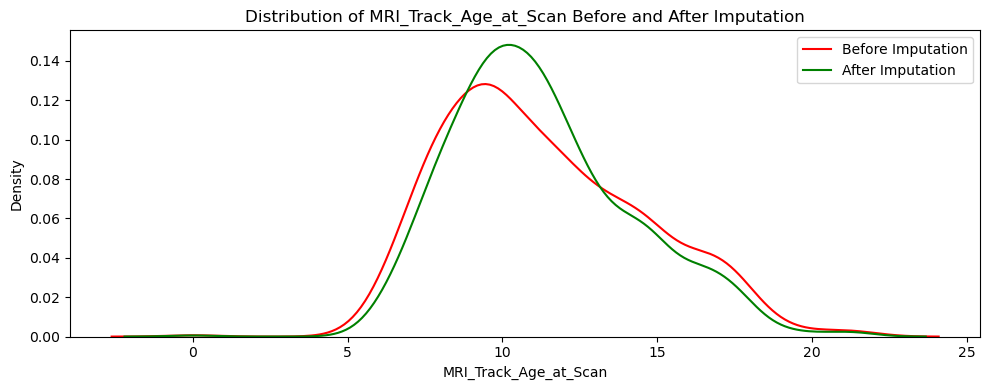

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

# Before Imputation
sns.kdeplot(metadata_a_train["MRI_Track_Age_at_Scan"], label="Before Imputation", color='red')

# After Imputation
sns.kdeplot(features_a_train_imputed["MRI_Track_Age_at_Scan"], label="After Imputation", color='green')

plt.title("Distribution of MRI_Track_Age_at_Scan Before and After Imputation")
plt.xlabel("MRI_Track_Age_at_Scan")
plt.legend()
plt.tight_layout()
plt.show()

### Metadata A – Distribution Insights After Imputation.

The above KDE plot compares the distribution of the column MRI_Track_Age_at_Scan before and after imputation.

- The red curve indicates how the missing values affected the distribution **before imputation** where I see a noticeable gap.
- The green curve shows the distribution **after imputatin**, which is smoother.

- My imputation codes do fill the missing values and do not distort the original distribution.

I can see from the result, this column is ready for further analysis or modelling.

### Feature Selection for Metadata A

### 6.5 Metadata A – Preparing Data for Feature Selection (Mutual Information)

In [22]:
#  I Extract the features (X) and target label (y)
X_a = features_a_train_imputed.drop(columns=["participant_id"])
y = labels_train.set_index("participant_id").loc[features_a_train_imputed["participant_id"], "ADHD_Outcome"]

# Check shape to confirm
print("Shape of features:", X_a.shape)
print("Shape of target:", y.shape)

Shape of features: (970, 18)
Shape of target: (970,)


### 6.6 Metadata A – Feature Selection Using Mutual Information

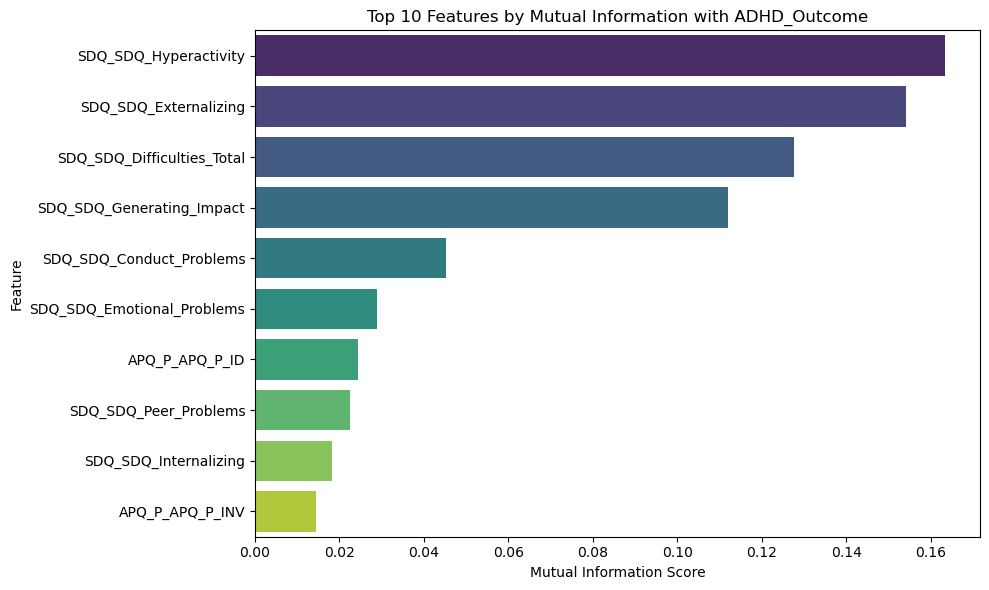

In [24]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") # i put this code for ignore the color error



# X_a = features (numerical), y = ADHD label
X_a = features_a_train_imputed.drop(columns=["participant_id"])
y = labels_train.set_index("participant_id").loc[features_a_train_imputed["participant_id"], "ADHD_Outcome"]

# I wrote this line of code to compute mutual information
mi_scores = mutual_info_classif(X_a, y, random_state=42)

# Build a dataframe of results
mi_df = pd.DataFrame({
    "Feature": X_a.columns,
    "Mutual Information": mi_scores
}).sort_values(by="Mutual Information", ascending=False)

#  I created a plot of the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x="Mutual Information", y="Feature", data=mi_df.head(10), palette="viridis")
plt.title("Top 10 Features by Mutual Information with ADHD_Outcome")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Metadata A – Feature Selection using Mutual Information.

I used **mutual information analysis** in this step to find the most informative features from the Metadata A (numerical) dataset with respect to the target label ADHD_Outcome.

### What I did:
- I removed the column participant_id from the feature matrix to prevent bias.
- I matched the features (X) and target labels (y) on the basis of participant id.
- With the mutual_info_classif from sklearn, I calculated the mutual information of all the features with respect to the ADHD diagnosis label.
- At last, I plotted the 10 best features with the highest scores.

### Insights:
- Most of the top features are SDQ related (SDQ_SDQ_Hyperactivity, SDQ_SDQ_Externalizing, SDQ_SDQ_Difficulties_Total, etc.), which is not surprising as the SDQ seeks to measure behaviors and emotions related to ADHD.

- Features associated with parenting styles like APQ_P_APQ_P_ID and APQ_P_APQ_P_INV do appear.

I mean ranking the variables within the database to help reduce dimensionality, at the modeling stage most important predictors will be chosen.

No missing values were present after imputation, and the variable X_a is now ready for modeling.

### 6.7 Final Feature Selection for Metadata A – Keeping Top 10 Features Only

In [26]:
# I Selected top 10 features based on mutual information
top_features = mi_df.head(10)["Feature"].tolist()

#  Filter training and test sets to keep only top features + participant_id
features_a_train_selected = features_a_train_imputed[top_features + ["participant_id"]]
features_a_test_selected = features_a_test_imputed[top_features + ["participant_id"]]

# Check shape to confirm
print("Train shape after feature selection:", features_a_train_selected.shape)
print("Test shape after feature selection:", features_a_test_selected.shape)

Train shape after feature selection: (970, 11)
Test shape after feature selection: (243, 11)


### Summary of the final Feature Selection – Keeping Top 10 Features Only


I computed mutual information score for each of the numerical features with respect to the label ADHD_Outcome and selected the top 10. This helps to reduce the dimensions and remove any useless data and also to focus the model on the most predictive variables.

### Why did I select only the top 10 features?

The top ten features which depend on the ADHD diagnosis showed a high dependency with it using mutual information.
Reducing the number of features.
Makes the model faster and less prone to overfitting.
Enhances clarity, especially when working with NHS doctors.
This took place after data split to avoid data leakage and after data imputation to avoid any missing values affecting the selection.
Features selected.

### Based on mutual information scores, the top 10 features are.

SDQ_SDQ_Hyperactivity.
SDQ_SDQ_Externalizing.
SDQ_SDQ_Difficulties_Total.
SDQ_SDQ_Generating_Impact.
SDQ_SDQ_Conduct_Problems.
SDQ_SDQ_Emotional_Problems.
APQ_P_APQ_P_ID.
SDQ_SDQ_Peer_Problems.
SDQ_SDQ_Internalizing.
APQ_P_APQ_P_INV.
The SDQ (strengths and difficulties questionnaire) and APQ (parenting questionnaire) derived features mainly used to capture emotions and behaviours along with parenting which is a strong association with ADHD. 

### Final datasets.

The final train and test sets now contain only.

These 10 selected features.
The participant_id column for traceability.
I will now finish feature selection for Metadata A, after which I will move on to this next dataset. 

### 6.8 Metadata B – Column Types and Missing Value Overview (Train Set)


In [28]:

# I'm checking the of column data types
print("Column Data Types:")
print(metadata_b_train.dtypes)

# I'm checking the missing values per column
print("\nMissing Values:")
print(metadata_b_train.isnull().sum())


Column Data Types:
participant_id                       object
Basic_Demos_Enroll_Year               int64
Basic_Demos_Study_Site                int64
PreInt_Demos_Fam_Child_Ethnicity    float64
PreInt_Demos_Fam_Child_Race           int64
MRI_Track_Scan_Location               int64
Barratt_Barratt_P1_Edu                int64
Barratt_Barratt_P1_Occ                int64
Barratt_Barratt_P2_Edu                int64
Barratt_Barratt_P2_Occ                int64
dtype: object

Missing Values:
participant_id                      0
Basic_Demos_Enroll_Year             0
Basic_Demos_Study_Site              0
PreInt_Demos_Fam_Child_Ethnicity    9
PreInt_Demos_Fam_Child_Race         0
MRI_Track_Scan_Location             0
Barratt_Barratt_P1_Edu              0
Barratt_Barratt_P1_Occ              0
Barratt_Barratt_P2_Edu              0
Barratt_Barratt_P2_Occ              0
dtype: int64


###  Summary of the Metadata B – Column Types and Missing Value Overview (Train Set)

I inspected the data types of the columns and identified missing values in the categorical dataset (Metadata B) – limited to the training set only.

#### Key Observations:

- All columns were initially loaded as numerical types (int64 or float64), even though some of them are categorical (e.g., race, education, occupation). This might lead to incorrect imputation if not fixed.
- One column that I could see above , PreInt_Demos_Fam_Child_Ethnicity, has 9 missing values.
- I saw all other columns have complete data (no NaNs).
- Since the column with missing data is categorical, and the data dictionary defines a valid placeholder (3 = "Unknown"), I will fill the missing values with 3 — which is the **recommended option**, according to my dear Dr.Ana
- While filling with the mode is technically valid, it is **not the best choice** in this case.
- Importantly, using the mean or median here would be **incorrect**, as the column was loaded as int64 but represents categorical information.

 Next step: I will convert relevant columns to category dtype before handling missing values.


### 6.9 Metadata B – Value Distribution Before Imputation (Train Set)


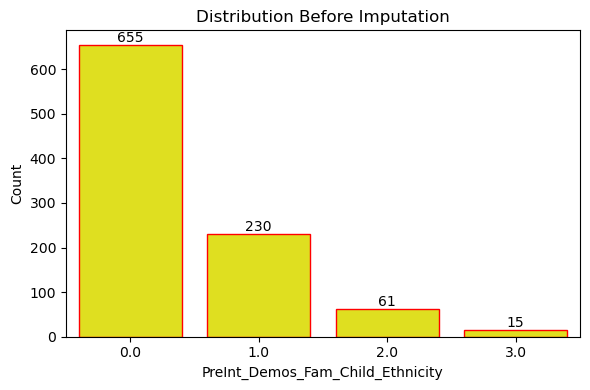

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot value distribution before imputation
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=metadata_b_train, x="PreInt_Demos_Fam_Child_Ethnicity", edgecolor='Red',color='Yellow')
plt.title("Distribution Before Imputation")
plt.xlabel("PreInt_Demos_Fam_Child_Ethnicity")
plt.ylabel("Count")

for p in ax.patches:
    height = int(p.get_height())
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    ax.annotate(f'{height}', (x, y), ha='center', va='bottom')
    
plt.tight_layout()
plt.show()


### Summary of the Metadata B – Distribution Analysis Before Imputation.

To create a suitable imputation strategy, I examined the distribution pattern of value for the column PreInt_Demos_Fam_Child_Ethnicity at train data. This step is essential because.

- The column has very few missing values.
- Since it was first loaded as int64, this can mislead the imputation method so that it treats it as numerical instead of categorical.
- Imputing incorrectly can introduce statistical bias, change the original value representation, or distort the value’s original semantic meaning.

### Key Observations from the Plot:

- I can see that Value 0 is dominating the distribution and is most likely the ethnic category with maximum counts.
- I notice that values 1 and 2 are in the data but are not as common. 
- I notice that the code **Value 3** does exist according to the data dictionary which refers to Unknown. Furthermore, I see that it appears pretty rarely at 15 instances in the rare data. This observation confirms that it is an authentic code and not an error.

### Imputation Decision:

I discovered that I would employ **placeholder value 3** to replace the missing values.   This decision is supported by both.

- The meaning of 3 is consistent with unknown.
- The data dictionary shows that this label is intentional.

### Outcome:

My understanding ensures that the imputation.

- The data maintains the category meaning on purpose.
- Does not create fake artificial bias or misleading statistics
- Help me to ensure the findings are valid and interpretable. Essential in a sensitive context such as NHS.


### 6.10 Metadata B – Imputing Categorical Column in Train and Test Sets Using Function


In [32]:
# I define a function to impute categorical values with a placeholder (e.g., 3 = "Unknown")
def impute_metadata_b(train_df, test_df, col_name, fill_value=3):
    # I convert the column to category dtype
    train_df[col_name] = train_df[col_name].astype("category")
    test_df[col_name] = test_df[col_name].astype("category")

    # Impute missing values with the specified fill_value
    train_df[col_name] = train_df[col_name].fillna(fill_value)
    test_df[col_name] = test_df[col_name].fillna(fill_value)

    # Print remaining missing values (I expected that should be zero)
    print(f"{col_name} – Train missing after imputation:", train_df[col_name].isnull().sum())
    print(f"{col_name} – Test missing after imputation:", test_df[col_name].isnull().sum())

    return train_df, test_df

# Call my function on the target column
metadata_b_train, metadata_b_test = impute_metadata_b(
    metadata_b_train,
    metadata_b_test,
    col_name="PreInt_Demos_Fam_Child_Ethnicity",
    fill_value=3  # 3 = "Unknown" according to data dictionary
)

#  I wrote this line of code to ensure about confirmation
print(" Imputation function executed successfully.")


PreInt_Demos_Fam_Child_Ethnicity – Train missing after imputation: 0
PreInt_Demos_Fam_Child_Ethnicity – Test missing after imputation: 0
 Imputation function executed successfully.


### Metadata B – Imputation of Categorical Column Using Placeholder ("Unknown").

I first converted column PreInt_Demos_Fam_Child_Ethnicity into category data type before imputation. Even though the column was loaded as int64, it is semantically categorical (e.g., coded ethnic group).

### Why this step matters:.

- If I don’t convert the column to category, many imputation functions or downstream processes might think it is numerical and make **incorrect assumptions**.
- When I change the column to category, the imputation logic (like filling in a temporary value like 3 = Unknown) knows to respect the semantics.
- It also helps in making clear further steps like feature selection or encoding where distinguishing numerical and categorical features is important.

I managed the missing values in categorical column PreInt_Demos_Fam_Child_Ethnicity from the Metadata B dataset. As per the data dictionary a 3 signifies Unknown. This one seems most appropriate to fill in that column per my dear Dr. Ana.                                                                                                                                                                                 


To make sure the training and test sets are both clean and will receive the same imputation, I.

- I made a reusable function called impute_metadata_b() which takes both datasets and fills the column with the placeholder.
- I used the function on training and test data sets.
- Both the datasets are complete, and there are no missing values.

This strategy was chosen because.
- Even though filling with mode is technically correct, it can create a distorted distribution.
- It is statistically wrong to use mean or median for imputation, as column is loaded as int64, though semantically it is **categorical** data.
- Filling the dataset with the number 3 agrees with its context and instructions.


Imputing with 3 preserves statistical correctness and also aligns with the semantics and documentation of the dataset.


### 6.11 Metadata B – Distribution of Categorical Column After Imputation (Train Set Only)

Value counts after imputation (Train Set):
PreInt_Demos_Fam_Child_Ethnicity
0.0    655
1.0    230
2.0     61
3.0     24
Name: count, dtype: int64


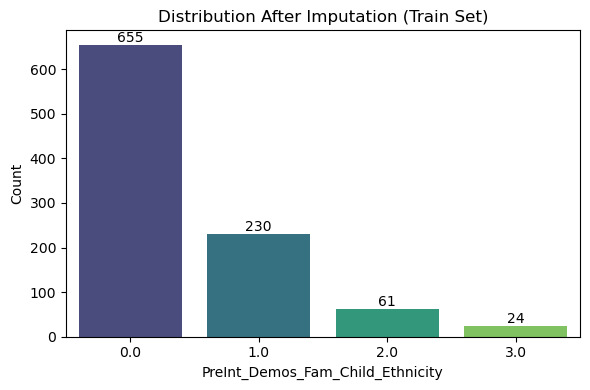

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Print value counts after imputation
print("Value counts after imputation (Train Set):")
print(metadata_b_train["PreInt_Demos_Fam_Child_Ethnicity"].value_counts())

#  Plot value distribution after imputation
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=metadata_b_train,
    x="PreInt_Demos_Fam_Child_Ethnicity",
    palette="viridis"
)
plt.title("Distribution After Imputation (Train Set)")
plt.xlabel("PreInt_Demos_Fam_Child_Ethnicity")
plt.ylabel("Count")

# Add value labels on top of bars
for p in ax.patches:
    height = int(p.get_height())
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    ax.annotate(f'{height}', (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Metadata B – Distribution After Imputation (Train Set).

To test the imputation process, I looked at the distribution of the PreInt_Demos_Fam_Child_Ethnicity column in the **training set** after imputation.

As shown in the bar chart above.

- The value that occurs the greatest number of times didn’t change, it remains **0** with a total of **655** participants, which means, the distribution’s original pattern is preserved.
- The proportions of categories 1 and 2 remain stable (230 and 61) respectively.
- The number of value 3, which is ‘unknown’ as per the data dictionary, goes up from 15 (as was present in the data) to 24 after imputation.
The value went up by 9 which is exactly the no. of missing values that were filled with fill_value=3.

 **This confirms that:**.
- All missing values received correct imputations (without any distortions).

- No Other Values were affected.
- The meaning of Unknown and its semantics are preserved, ensuring no misrepresentation of data documentation.

It is important to perform this check before any further machine learning activities or encoding of categorical variables. 


### 6.12 Feature Selection in Metadata B – Top 10 Categorical Features using Mutual Information

In [36]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

#  I need to keepping a backup of full metadata for participant_id recovery
metadata_b_train_full = metadata_b_train.copy()
metadata_b_test_full = metadata_b_test.copy()

#  I dropped  ID column from train set before feature selection
metadata_b_train_feat = metadata_b_train.drop(columns=["participant_id"]).copy()

#  It is necessary that I convert all categorical features to category dtype
for col in metadata_b_train_feat.columns:
    metadata_b_train_feat[col] = metadata_b_train_feat[col].astype("category")

# Also,I encode categorical features for mutual information
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(metadata_b_train_feat)

# Define target variable (ADHD)
y = labels_train["ADHD_Outcome"]

#  Compute mutual information scores
mi_scores = mutual_info_classif(X_encoded, y, discrete_features=True, random_state=42)

# I create a DataFrame of feature scores with my code
mi_df = pd.DataFrame({
    "Feature": metadata_b_train_feat.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)

#  I'm selecting the top 5 categorical features
top_5_features = mi_df["Feature"].head(5).tolist()
print("Top 5 features:", top_5_features)

# I kept only selected features in metadata_b_train and metadata_b_test
metadata_b_train = metadata_b_train_full[top_5_features + ["participant_id"]]
metadata_b_test = metadata_b_test_full[top_5_features + ["participant_id"]]

print('\n')

print(" metadata_b_train now contains top 5 selected features + participant_id.")
print(" metadata_b_test remains unchanged for now (no feature selection applied yet).")


Top 5 features: ['Basic_Demos_Enroll_Year', 'MRI_Track_Scan_Location', 'PreInt_Demos_Fam_Child_Race', 'Barratt_Barratt_P1_Occ', 'Basic_Demos_Study_Site']


 metadata_b_train now contains top 5 selected features + participant_id.
 metadata_b_test remains unchanged for now (no feature selection applied yet).


### 6.13 Visualizing Mutual Information of Top 5 Features

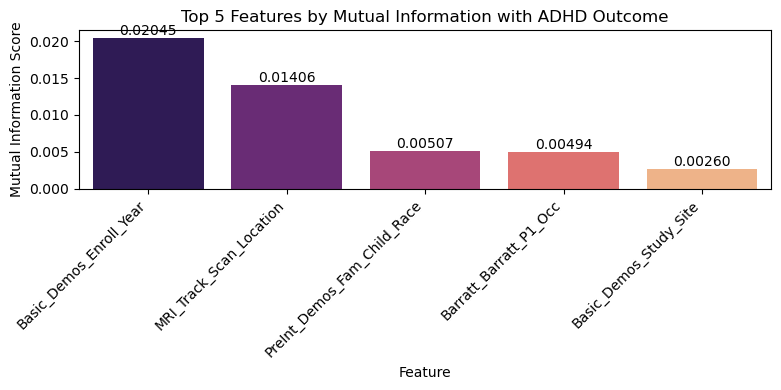

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Filter the MI DataFrame for top 5 features only
top_5_mi_df = mi_df[mi_df["Feature"].isin(top_5_features)]

#  I'm Plotting
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=top_5_mi_df, x="Feature", y="MI_Score", palette="magma")

# I add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.5f}", (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.title("Top 5 Features by Mutual Information with ADHD Outcome")
plt.xlabel("Feature")
plt.ylabel("Mutual Information Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Feature Selection in Metadata B – Analysis of Top 5 Categorical Features.

I’ve used Mutual Information (MI) to identify the strongest categorical features in Metadata B that predict ADHD outcome. The analysis was done on the imputed training set.

Summary of the Process:.
- The OrdinalEncoder properly encoded all categorical columns.
- MI Scores Were Calculated Using mutual_info_classif() With Discrete Features=True, Because All Columns Are Categorical. 
- The five features with the highest MI score were selected for purpose of modeling and interpreting.

Top 5 Features Identified:
1. Basic_Demos_Enroll_Year.
2. MRI_Track_Scan_Location.
3. PreInt_Demos_Fam_Child_Race.
4. Barratt_Barratt_P1_Occ.
5. Basic_Demos_Study_Site.

These features had the highest mutual information with target ADTH Outcome indicating highest difference-making or information in distinguishing ADHD from non-ADHD participants.

Visual Confirmation:.
The barplot indicates that the two features with the maximum MI score are Enroll Year and Scan Location. Even though the other features are low MI value, they are not zero MI value hence they have predictive power.

Why This Step Matters:.
- This helps me select features that have the biggest impact on the output (the target column).
- It makes it easier to understand the model.

- It improves the interpretability of the model and improves training.

I only use attributes that are meaningful for the domain to achieve better computational efficiency in a model.


### 6.14 Brain Connectome – Feature Selection Using KernelPCA

In [40]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

#  At first I separate participant_id
X_train_connectome = connectome_train.drop(columns="participant_id").copy()
X_test_connectome = connectome_test.drop(columns="participant_id").copy()

# I made sure for NaNs (should be zero)
assert X_train_connectome.isnull().sum().sum() == 0
assert X_test_connectome.isnull().sum().sum() == 0

# Apply KernelPCA
kpca = KernelPCA(n_components=30, kernel="rbf", gamma=0.0005, random_state=42)
X_train_kpca = kpca.fit_transform(X_train_connectome)
X_test_kpca = kpca.transform(X_test_connectome)

# I convert back to DataFrame and reattach participant_id that I seperated at first of my code
columns_kpca = [f"connectome_PC{i+1}" for i in range(X_train_kpca.shape[1])]
connectome_train_kpca = pd.DataFrame(X_train_kpca, columns=columns_kpca)
connectome_test_kpca = pd.DataFrame(X_test_kpca, columns=columns_kpca)

connectome_train_kpca["participant_id"] = connectome_train["participant_id"].values
connectome_test_kpca["participant_id"] = connectome_test["participant_id"].values

# I showed the final shape
print("Transformed train shape:", connectome_train_kpca.shape)
print("Transformed test shape:", connectome_test_kpca.shape)


Transformed train shape: (970, 31)
Transformed test shape: (243, 31)


### Brain Connectome – Feature Selection using KernelPCA.

At this step, I applied (KernelPCA) kernel principal component analysis to reduce dimensionality of the high-dimensional connectome dataset. The dataset was utilized to have 19,901 numerical features for each participant which were functional connectivity between the brain regions in a pair-wise manner.

### Why KernelPCA?

The earlier data analysis that I did, KernelPCA is used due to the following observations.
- The variables in the connectome columns don’t have quite strong correlation.
- Using an RBF kernel for KernelPCA is important because it allows for non-linearity in the data. KernelPCA is applied to the brain connectomes as their dimensions are 1300, which is a lot and is used to reduce dimensions.

### Implementation Summary:
- I first dropped the participant_id column and checked that no missing value is present in train and test sets.
- I implemented KernelPCA with the following configuration: 
- n_components=30
- kernel=rbf
- I picked the gamma value of 0.0005 arbitrarily. I will tune it in case it is required during modeling.
- I reconstructed DataFrames for train and test sets after transformation, attaching back participant_id for easy identification.

### Output:
- Tshape of training data after transformation
- The shape of the transformed test is (243, 31).
These are 30 kernel components along with participant_id.

 I will utilize these modified features in the modeling phase now. They should hold the most informative nonlinear structure in the original connectome data.

### Why KernelPCA Was Applied This Way (Train Only for Fitting).

I used KernelPCA to reduce the high dimensionality of the Brain Connectome data in this step. But, correct ML practice is to avoid any **data leakage.**

- I only used fit_transform() on the training set.
- I performed transform() only on the test set.

This makes sure that the KernelPCA model learns the transformation based only on the training data, without any knowledge of the test set. Using KernelPCA is similar to using scaling or imputing, thus should always fit on training data only.

### By doing this
- I always apply the feature space on the test data learned from the training data.
- It helps to avoid leakage and ensures that the validity of the model is based on unseen data.

Following established machine learning practice helps support the use of proper ML pipelines.




## 7. Merging the Data

### 7.1 Renaming Feature-Selected Metadata A Sets for Export

In [57]:
# I Renamed feature-selected Metadata A to expected export names
metadata_a_train_selected = features_a_train_selected
metadata_a_test_selected = features_a_test_selected

print("Renamed feature-selected Metadata A sets successfully.")


Renamed feature-selected Metadata A sets successfully.


### 7.2 Exporting Final Cleaned and Reduced Datasets to CSV Files

In [59]:
# I'm Creating a folder for saving processed CSVs
import os
os.makedirs("../processed_data", exist_ok=True)

# I Saved the processed training and test datasets
metadata_a_train_selected.to_csv("../processed_data/metadata_a_train_selected.csv", index=False)
metadata_a_test_selected.to_csv("../processed_data/metadata_a_test_selected.csv", index=False)

metadata_b_train.to_csv("../processed_data/metadata_b_train.csv", index=False)
metadata_b_test.to_csv("../processed_data/metadata_b_test.csv", index=False)

connectome_train_kpca.to_csv("../processed_data/connectome_train_kpca.csv", index=False)
connectome_test_kpca.to_csv("../processed_data/connectome_test_kpca.csv", index=False)

labels_train.to_csv("../processed_data/labels_train.csv", index=False)
labels_test.to_csv("../processed_data/labels_test.csv", index=False)


# I set final confirmation message
print(" All cleaned and reduced datasets were successfully exported to the folder './processed_data'.")


 All cleaned and reduced datasets were successfully exported to the folder './processed_data'.


### 7.3 Merging All Processed Data into Final Train and Test Sets


In [61]:
import pandas as pd
import os

#  I created a separate output folder for my final dataset for my modelling
os.makedirs("../final_data", exist_ok=True)

# I load all processed datasets from my processed_data folder
metadata_a_train = pd.read_csv("../processed_data/metadata_a_train_selected.csv")
metadata_a_test = pd.read_csv("../processed_data/metadata_a_test_selected.csv")

metadata_b_train = pd.read_csv("../processed_data/metadata_b_train.csv")
metadata_b_test = pd.read_csv("../processed_data/metadata_b_test.csv")

connectome_train = pd.read_csv("../processed_data/connectome_train_kpca.csv")
connectome_test = pd.read_csv("../processed_data/connectome_test_kpca.csv")

labels_train = pd.read_csv("../processed_data/labels_train.csv")
labels_test = pd.read_csv("../processed_data/labels_test.csv")

# I Merged the final training set
final_train = (
    metadata_a_train
    .merge(metadata_b_train, on="participant_id")
    .merge(connectome_train, on="participant_id")
    .merge(labels_train, on="participant_id")
)

# Also, I used the same method for merging the final test set
final_test = (
    metadata_a_test
    .merge(metadata_b_test, on="participant_id")
    .merge(connectome_test, on="participant_id")
    .merge(labels_test, on="participant_id")
)

#  Save merged datasets
final_train.to_csv("../final_data/final_train_dataset.csv", index=False)
final_test.to_csv("../final_data/final_test_dataset.csv", index=False)
#  I set these confirmation messages
print("Final merged datasets saved in 'final_data/' folder:")
print("final_train_dataset.csv")
print("final_test_dataset.csv")

# I also printed the shapes of the datasets to confirm the merging was successful and the structure is consistent.
print("\n Final dataset shapes:")
print("Train set shape:", final_train.shape)
print("Test set shape :", final_test.shape)



Final merged datasets saved in 'final_data/' folder:
final_train_dataset.csv
final_test_dataset.csv

 Final dataset shapes:
Train set shape: (970, 48)
Test set shape : (243, 48)


### Merging All Processed Data into Final Train and Test Sets.

I merged the clean and feature-selected datasets Metadata A, Metadata B, Connectome, and Labels into combined training and test sets in this step. I performed the merging using the participant_id key for the various datasets.

I utilized the final datasets in the processed_data folder. I saved the final merged train and test sets in a new folder final_data.
The datasets are now ready to use in modeling phase.

The final training and test datasets include.
- Ten features chosen from Metadata A
- Five most important characteristics from Metadata B.
- Reduced the dimension of connectome features through KernelPCA
- Target variables (ADHD_Outcome, Sex_F).
